In [18]:
from embeddings.SBERT import encode_sentences
from measure_diversity.measure import mean_pairwise_distance, distance_dispersion, cluster_inertia_diversity, convex_hull_volume
import os

In [19]:
def read_sentences_from_txt(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


In [39]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("")))
DATA_PATH_high = os.path.join(BASE_DIR, "Diversity-Measurement/pilot_datasets/semantic_diversity/reuters_8-topic.txt")
DATA_PATH_low = os.path.join(BASE_DIR, "Diversity-Measurement/pilot_datasets/semantic_diversity/reuters_2-topic.txt")

In [40]:
sentences_high = read_sentences_from_txt(DATA_PATH_high)
print(f"Loaded {len(sentences_high)} sentences.")
print(sentences_high[:3])

sentences_low = read_sentences_from_txt(DATA_PATH_low)
print(f"Loaded {len(sentences_low)} sentences.")
print(sentences_low[:3])

Loaded 80 sentences.
["Australia's seasonally adjusted unemployment rate rose to 8.4 pct of the estimated workforce in March from 8.2 pct in February and 7.9 pct a year earlier, the Statistics Bureau said. The number of jobless rose to 650,700 from 631,900 in February and 593,200 a year earlier, the Bureau said. Unadjusted, the number of unemployed rose to 702,600 from 699,600 in February but the rate eased to 9.0 pct from 9.1, reflecting a slight increase in the estimated workforce. In March 1986, 640,400 persons, or 8.5 pct of the workforce, were out of work.", 'The Bank of England said it had revised its estimate of the shortage in the money market today up to 1.15 billion stg before taking account of its early operations. Earlier, the bank forecast the deficit at 1.05 billion stg and gave 90 mln stg assistance at an early round of bill offers.', 'French unemployment rose to a record seasonally adjusted 2.65 mln in February from 2.61 mln in January and 2.57 mln at the end of last ye

In [41]:
embeddings_high = encode_sentences(sentences_high)
print(f"Embedding shape: {len(embeddings_high)} x {len(embeddings_high[0])}")

embeddings_low = encode_sentences(sentences_low)
print(f"Embedding shape: {len(embeddings_low)} x {len(embeddings_low[0])}")


Embedding shape: 80 x 384
Embedding shape: 80 x 384


In [42]:
print("High Diversity:")
print("Mean Pairwise Distance:", mean_pairwise_distance(embeddings_high))
print("Distance Dispersion:", distance_dispersion(embeddings_high))
print("Cluster Inertia Diversity:", cluster_inertia_diversity(embeddings_high))
try:
    print("Convex Hull Volume:", convex_hull_volume(embeddings_high))
except Exception as e:
    print("Convex Hull Volume: error -", e)

print("\nLow Diversity:")
print("Mean Pairwise Distance:", mean_pairwise_distance(embeddings_low))
print("Distance Dispersion:", distance_dispersion(embeddings_low))
print("Cluster Inertia Diversity:", cluster_inertia_diversity(embeddings_low))
try:
    print("Convex Hull Volume:", convex_hull_volume(embeddings_low))
except Exception as e:
    print("Convex Hull Volume: error -", e)


High Diversity:
Mean Pairwise Distance: 0.7819487278538231
Distance Dispersion: 2470.957980018081
Cluster Inertia Diversity: 39.906437401352115
Convex Hull Volume: error - Cannot compute convex hull for fewer than dimension+1 385 points (got 80)

Low Diversity:
Mean Pairwise Distance: 0.7159912540490441
Distance Dispersion: 2262.5323627949792
Cluster Inertia Diversity: 29.494784243051768
Convex Hull Volume: error - Cannot compute convex hull for fewer than dimension+1 385 points (got 80)


/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/measure_diversity/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


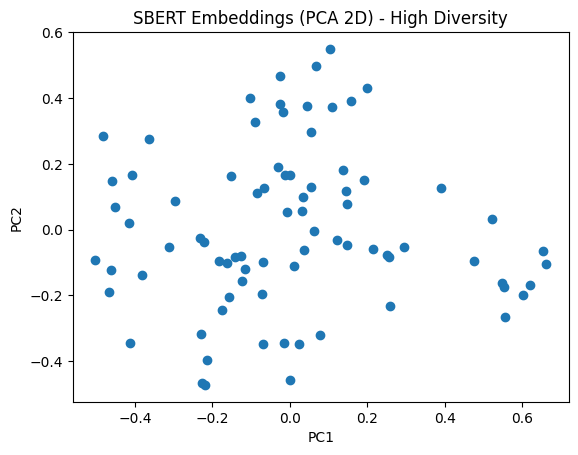

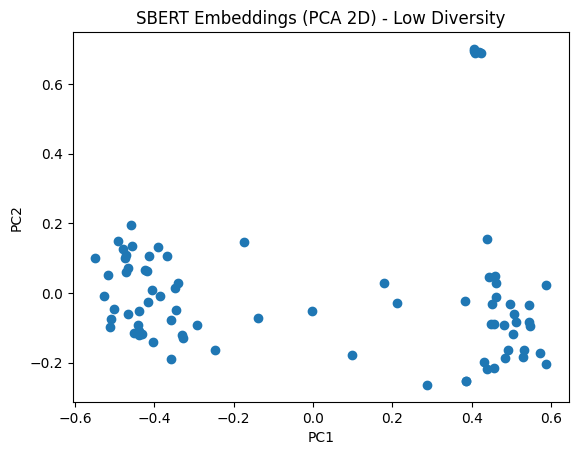

In [44]:
pca = PCA(n_components=2)
embeddings_2d_high = pca.fit_transform(embeddings_high)
plt.scatter(embeddings_2d_high[:,0], embeddings_2d_high[:,1])
plt.title("SBERT Embeddings (PCA 2D) - High Diversity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pca = PCA(n_components=2)
embeddings_2d_low = pca.fit_transform(embeddings_low)
plt.scatter(embeddings_2d_low[:,0], embeddings_2d_low[:,1])
plt.title("SBERT Embeddings (PCA 2D) - Low Diversity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


